<h1><center>"Multi-Table E-Commerce European Fashion"</center></h1>

### **1. Importing Libraries**

In [12]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Loading Database from SQL**

In [15]:
user = "postgres"
password = quote_plus("*****") # ***** -> my password
host = "localhost"
port = "5432"
database = "01_portfolio_ecommerce_EN"

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

### **3. Defining Table to Use**

In [16]:
e_commerce = pd.read_sql("SELECT * FROM sales_analysis", engine)

e_commerce.head()

,sale_id,sale_date,sale_channel,sale_discounted,total_amount,sale_country,customer_id,age_range,signup_date,item_id,...,catalog_price,cost_price,gender,campaign_id,campaign_name,campaign_start_date,campaign_end_date,campaign_channel,discount_type,discount_value
0,172,2025-05-13,App Mobile,True,178.20,Spain,398,16-25,2025-01-26,2394,...,28.98,19.66,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0
1,986,2025-05-23,App Mobile,False,229.64,France,735,26-35,2025-04-02,1631,...,16.69,8.37,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0
2,724,2025-05-30,E-commerce,False,183.62,France,227,46-55,2025-04-23,685,...,15.31,8.95,Female,6,June Price Drop,2025-06-01,2025-06-09,Website Banner,Percentage,10.0
3,658,2025-06-16,App Mobile,False,374.25,Portugal,835,46-55,2025-04-26,2270,...,81.80,45.12,Female,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.0
4,336,2025-06-17,E-commerce,False,536.47,France,790,16-25,2025-04-26,1170,...,81.79,35.02,Female,6,June Price Drop,2025-06-01,2025-06-09,Website Banner,Percentage,10.0


### **4. Data Cleaning and Manipulation**

#### **4.1. Exploring the Dataset**

In [17]:
# Checking dataset size, column names, null values, and data types
e_commerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2411 entries, 0 to 2410
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              2411 non-null   int64  
 1   sale_date            2411 non-null   object 
 2   sale_channel         2411 non-null   object 
 3   sale_discounted      2411 non-null   bool   
 4   total_amount         2411 non-null   float64
 5   sale_country         2411 non-null   object 
 6   customer_id          2411 non-null   int64  
 7   age_range            2411 non-null   object 
 8   signup_date          2411 non-null   object 
 9   item_id              2411 non-null   int64  
 10  product_id           2411 non-null   int64  
 11  quantity             2411 non-null   int64  
 12  original_price       2411 non-null   float64
 13  unit_price           2411 non-null   float64
 14  discount_applied     2411 non-null   float64
 15  discount_percent     2411 non-null   f

#### The dataset consists of 20,411 rows and 34 columns. All columns are well-labeled and null-free. Type conversion is required for 'sale_date', 'signup_date', 'campaign_start_date', and 'campaign_end_date', which must be transformed from 'object' to 'datetime' format."

#### **4.2. Data Type Conversion**

In [18]:
# Define columns for dtype correction
cols = ["sale_date", "signup_date", "campaign_start_date", "campaign_end_date"]

# Convert data types to datetime
e_commerce[cols] = e_commerce[cols].apply(pd.to_datetime, errors = "coerce")

# Verify changes
print(e_commerce[cols].dtypes)

sale_date              datetime64[ns]
signup_date            datetime64[ns]
campaign_start_date    datetime64[ns]
campaign_end_date      datetime64[ns]
dtype: object


#### **4.3. Checking for Duplicates**

In [19]:
# Checking for exact duplicates
e_commerce[e_commerce.duplicated()]

,sale_id,sale_date,sale_channel,sale_discounted,total_amount,sale_country,customer_id,age_range,signup_date,item_id,...,catalog_price,cost_price,gender,campaign_id,campaign_name,campaign_start_date,campaign_end_date,campaign_channel,discount_type,discount_value


#### No duplicates were found in the dataset.

### **5. Exploratory Data Analysis (EDA)**

#### **5.1. Defining Variables for Analysis**

In [20]:
#Generating variables
e_commerce["year_month"] = e_commerce["sale_date"].dt.to_period("M").astype(str) # Extract month
e_commerce["profit_unit"] = e_commerce["unit_price"] - e_commerce["cost_price"] # Profit per unit
e_commerce["profit_total"] = e_commerce["profit_unit"] * e_commerce["quantity"] # Total profit
e_commerce["discount_rate_calc"] = np.where(e_commerce["original_price"] > 0, # Discount proportion
                                (e_commerce["original_price"] - e_commerce["unit_price"]) / e_commerce["original_price"], 0)

#### **5.2. Defining KPIs**

In [21]:
# Defining general KPIs
kpis = {
    "rows": len(e_commerce), # Total number of rows
    "unique_sales": e_commerce['sale_id'].nunique(), # Total unique sales
    "unique_customers": e_commerce["customer_id"].nunique(), # Total unique customers
    "unique_products": e_commerce["product_id"].nunique(), # Total unique products
    "revenue_items": round(e_commerce["item_total"].sum(), 2), # Total revenue from items sold
    "estimated_profit": round(e_commerce["profit_total"].sum(), 2), # Total estimated profit
    "avg_order_value": round(e_commerce.groupby("sale_id")["item_total"].sum().mean(), 2) # Average ticket size per order
}

# Displaying KPIs
kpis

{'rows': 2411,
 'unique_sales': 905,
 'unique_customers': 580,
 'unique_products': 499,
 'revenue_items': np.float64(336230.42),
 'estimated_profit': np.float64(143990.95),
 'avg_order_value': np.float64(371.53)}

#### **5.3. Calculating Revenue by Channel**

In [22]:
# Create new DataFrame with relevant variables
sales_by_channel = (
    e_commerce.groupby("sale_channel", as_index = False).agg(
        revenue = ("item_total", "sum"),
        units_sold = ("quantity", "sum"),
        orders = ("sale_id", "nunique")
    )
    .sort_values("revenue", ascending = False)
)

# Display DataFrame
sales_by_channel

,sale_channel,revenue,units_sold,orders
1,E-commerce,174000.54,3561,473
0,App Mobile,162229.88,3476,432


#### **5.4. Calculating Revenue by Country**

In [23]:
# Create new DataFrame with selected variables
sales_by_country = (
    e_commerce.groupby("sale_country", as_index = False).agg(
        revenue = ("item_total", "sum"),
        orders = ("sale_id", "nunique"),
        customers = ("customer_id", "nunique")
    )
    .sort_values("revenue", ascending = False)
)

# Display DataFrame
sales_by_country

,sale_country,revenue,orders,customers
1,Germany,77286.07,212,145
0,France,74332.98,199,125
2,Italy,62609.38,170,103
3,Netherlands,48363.94,131,84
5,Spain,42613.30,113,75
4,Portugal,31024.75,80,48


#### **5.5. Calculating Revenue by Category**

In [24]:
# Create new DataFrame with selected variables
top_categories = (
    e_commerce.groupby("category", as_index = False).agg(
        revenue = ("item_total", "sum"),
        units_sold = ("quantity", "sum"),
        estimated_profit = ("profit_total", "sum")
    )
    .sort_values("revenue", ascending = False)
)

# Display DataFrame
top_categories

,category,revenue,units_sold,estimated_profit
4,T-Shirts,72969.06,1523,31568.67
2,Shoes,71850.36,1448,31013.63
0,Dresses,71432.39,1537,30583.95
3,Sleepwear,64384.25,1422,26327.49
1,Pants,55594.36,1107,24497.21


#### **5.6. Calculating Revenue by Month**

In [25]:
# Create new DataFrame with selected variables
monthly_sales = (
    e_commerce.groupby("year_month", as_index = False).agg(
        revenue = ("item_total", "sum"),
        units_sold = ("quantity", "sum"),
        estimated_profit = ("profit_total", "sum")
    )
    .sort_values("revenue", ascending = False)
)

# Display DataFrame
monthly_sales

,year_month,revenue,units_sold,estimated_profit
1,2025-05,152027.39,3306,62553.02
0,2025-04,134456.64,2713,59532.76
2,2025-06,49746.39,1018,21905.17


#### **5.7. Revenue by Discounted vs. Non-discounted Items** 

In [26]:
# Calculating metrics for discounted vs. non-discounted products
discount_analysis = (
    e_commerce.groupby("item_discounted", as_index = False).agg(
        revenue = ("item_total", "sum"),
        avg_discount_pct = ("discount_percent", "mean"),
        units_sold = ("quantity", "sum"),
        estimated_profit = ("profit_total", "sum")
    )
)

# Display DataFrame
discount_analysis

,item_discounted,revenue,avg_discount_pct,units_sold,estimated_profit
0,False,300663.83,0.000000,6082,134898.76
1,True,35566.59,24.684211,955,9092.19


#### **5.8. Calculating Revenue by Age Group**

In [27]:
# Create new DataFrame with selected variables
age_analysis = (
    e_commerce.groupby("age_range", as_index = False).agg(
        revenue = ("item_total", "sum"),
        orders = ("sale_id", "nunique"),
        customers = ("customer_id", "nunique")
    )
    .sort_values("age_range")
)

# Display DataFrame
age_analysis

,age_range,revenue,orders,customers
0,16-25,68201.00,181,116
1,26-35,72034.86,189,121
2,36-45,71131.78,188,122
3,46-55,64715.51,176,111
4,56-65,60147.27,171,110


### **6. Data Visualization**

In [28]:
sns.set_style("whitegrid") # Set default grid background for charts

#### **6.1. Revenue by Sale Channel**

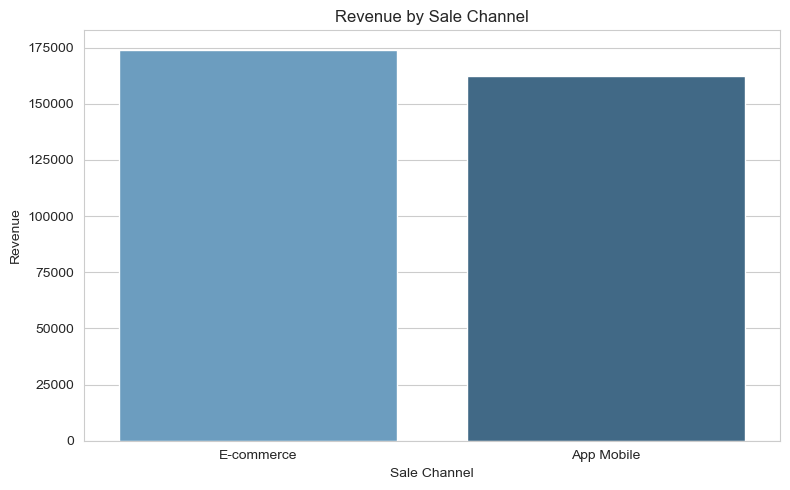

In [29]:
plt.figure(figsize = (8,5))
sns.barplot(data = sales_by_channel, x = "sale_channel", y = "revenue", hue = "sale_channel", palette = "Blues_d", legend = False)
plt.title("Revenue by Sale Channel")
plt.xlabel("Sale Channel")
plt.ylabel("Revenue")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

**Key Insight:** E-commerce (website) leads with approximately 52% of total revenue, while the mobile app contributes a solid 48%.

**Recommendation:** Prioritize the website, but maintain consistent support for the mobile app.

**Details:**
- E-commerce: €174,000.54 (51.8% of total)
- Mobile App: €162,229.88 (48.2% of total)

#### **6.2. Revenue by Country**

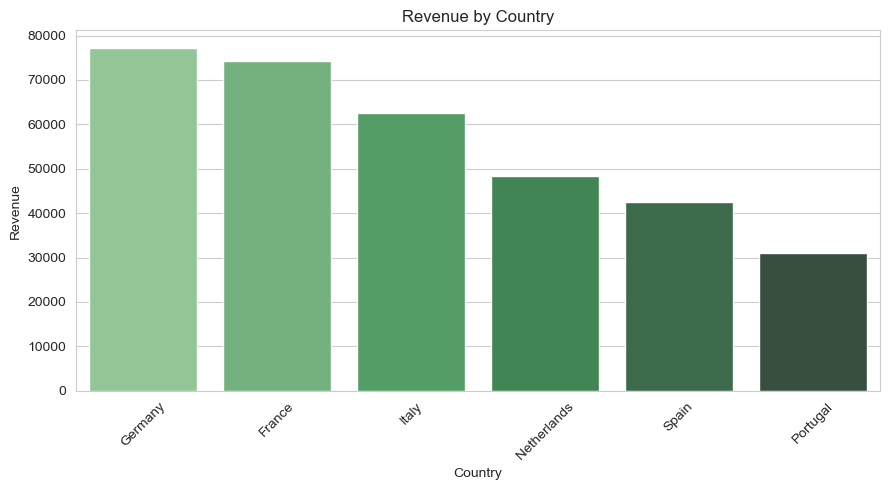

In [30]:
plt.figure(figsize = (9,5))
sns.barplot(data = sales_by_country, x = "sale_country", y = "revenue", hue = "sale_country", palette = "Greens_d", legend = False)
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Key Insight:** Germany leads with 23% of total revenue, followed by France (22.1%) and Italy (18.6%). These three countries account for over 60% of total revenue (63.7%).

**Recommendation:** Replicate successful sales strategies from Germany, France, and Italy in the Netherlands, Spain, and Portugal.

**Details:**
- Germany: €77,286.07 (23.0% of total)
- France: €74,332.98 (22.1% of total)
- Italy: €62,609.38 (18.6% of total)
- Other countries: 36.3%

#### **6.3. Revenue by Categories**

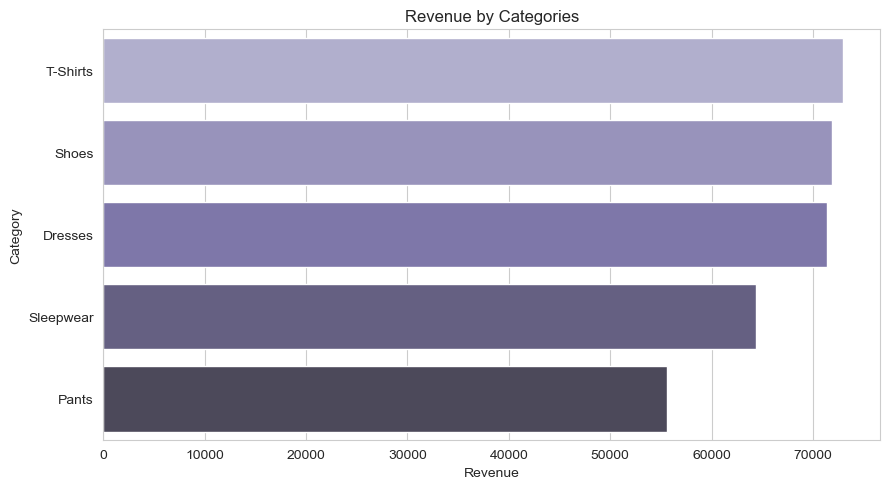

In [31]:
plt.figure(figsize = (9,5))
sns.barplot(data = top_categories, x = "revenue", y = "category", hue = "category", palette = "Purples_d", legend = False)
plt.title("Revenue by Categories")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

**Key Insight:** There is a remarkable revenue balance among the top categories: T-shirts (21.7%), Shoes (21.4%), and Dresses (21.2%). Together, these categories account for 64.3% of total revenue.

**Recommendation:** Maintain a balanced inventory mix for the top 3 categories and analyze the remaining 35.7% to identify categories with growth potential.

**Details:**
- T-shirts: €72,969.06 (21.7% of total)
- Shoes: €71,850.36 (21.4% of total)
- Dresses: €71,432.39 (21.2% of total)
- Other items: 35.7%

#### **6.4. Revenue by Month**

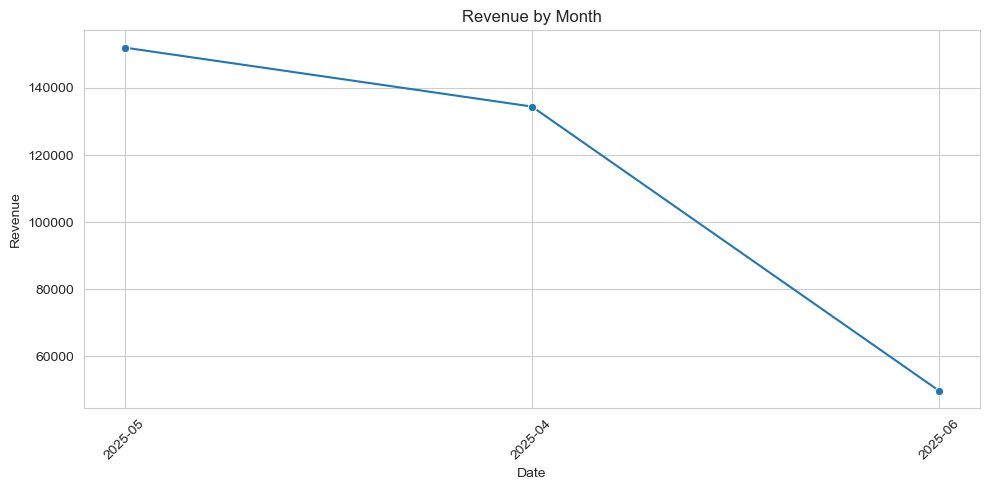

In [35]:
plt.figure(figsize = (10,5))
sns.lineplot(data = monthly_sales, x = "year_month", y = "revenue", marker = "o")
plt.title("Revenue by Month")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Key Insight:** Among the three months considered, May leads with 45.2% of total revenue, closely followed by April with 40%. Revenue drops significantly in June to 14.8%.

**Recommendation:** Analyze sales strategies used in April-May and investigate potential seasonality effects for June (start of summer in Europe).

**Details:**
- April 2025: €134,456.64 (40.0% of total)
- May 2025: €152,027.39 (45.2% of total)
- June 2025: €49,746.39 (14.8% of total)

#### **6.5. Revenue by Discounted vs. Non-discounted Items**

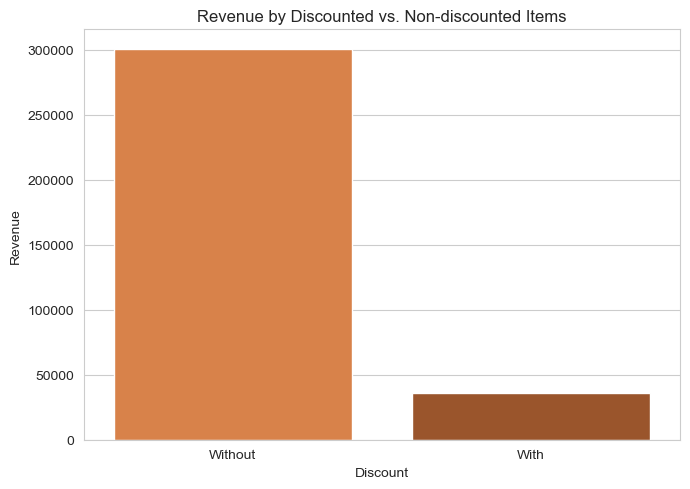

In [34]:
# Map True/False values to With/Without
discount_analysis["item_discounted"] = discount_analysis["item_discounted"].map({True: "With", False: "Without"})

plt.figure(figsize = (7,5))
sns.barplot(data = discount_analysis, x = "item_discounted", y = "revenue", hue = "item_discounted", palette = "Oranges_d", legend = False)
plt.title("Revenue by Discounted vs. Non-discounted Items")
plt.xlabel("Discount")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Key Insight:** There is a significantly higher revenue from non-discounted items compared to discounted items, with a wide margin (89.4% vs. 10.6%, respectively).

**Recommendation:**  Implement selective and targeted discounting strategies for specific products.

**Details:**
- No Discount: €300,663.83 (89.4% of total)
- Discounted: €35,566.59 (10.6% of total)

#### **6.6. Revenue by Age Group**

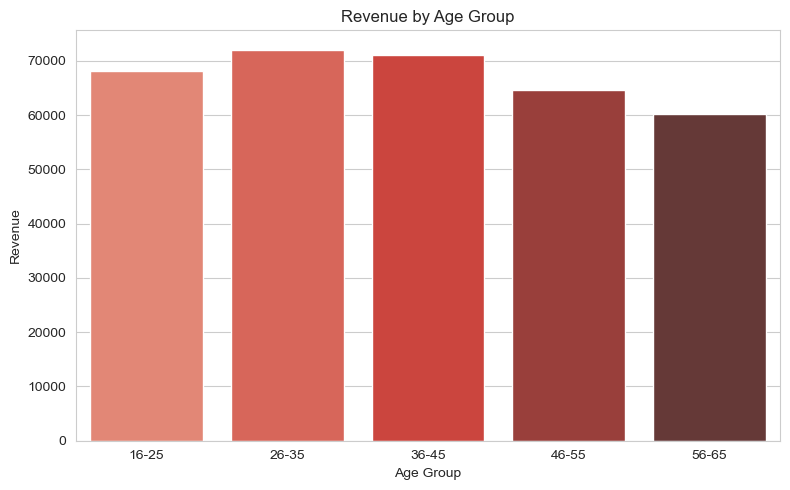

In [33]:
plt.figure(figsize = (8,5))
sns.barplot(data = age_analysis, x = "age_range", y = "revenue", hue = "age_range", palette = "Reds_d", legend = False)
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

**Key Insight:** Revenue is distributed relatively evenly across age groups, with the strongest performance in the 26-35 (21.4%) and 36-45 (21.2%) segments.

**Recommendation:** Focus campaigns on high-revenue age groups while adjusting marketing strategies to improve engagement from lower-contributing segments.

**Details:**
- 16-25: €68,201.00 (20.3% of total)
- 26-35: €72,034.86 (21.4% of total)
- 36-45: €71,131.78 (21.2% of total)
- 46-55: €64,715.51 (19.2% of total)
- 56-65: €60,147.27 (17.9% of total)

### **7. Exporting Dataframe**

In [32]:
# Export DataFrame for Tableau analysis
e_commerce.to_csv("e_commerce.csv", index = False)